In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# CREATE SAMPLE DATASET WITH CAFE LOCATIONS
data = {
    "Cafe": ["p1", "p2", "p3", "p4", "p5", "p6", "p7", "p8", "p9", "p10", "p11", "p12"],
    "Longitude": [4.5, 5, 6, 7, 9, 7, 8, 9, 4, 3, 4, 3.5],
    "Latitude": [8, 7, 6.5, 5, 4, 3, 3.5, 5, 4, 7.5, 6, 5],
}

# CONVERT DICTIONARY TO DATAFRAME
cafe_data = pd.DataFrame(data)

In [28]:
print("=>> CAFE LOCATION DATASET >>")
display(cafe_data)

=>> CAFE LOCATION DATASET >>


,Cafe,Longitude,Latitude
0,p1,4.5,8.0
1,p2,5.0,7.0
2,p3,6.0,6.5
3,p4,7.0,5.0
4,p5,9.0,4.0
5,p6,7.0,3.0
6,p7,8.0,3.5
7,p8,9.0,5.0
8,p9,4.0,4.0
9,p10,3.0,7.5


In [29]:
# CALCULATE MEAN LONGITUDE (DEMONSTRATION)
mean_longitude = cafe_data["Longitude"].sum() / cafe_data["Longitude"].count()
print(f":> MEAN LONGITUDE: {mean_longitude:.2f}")

:> MEAN LONGITUDE: 5.83


In [30]:
# INITIALIZE STANDARD SCALER FOR FEATURE NORMALIZATION
scaler = StandardScaler()


# SCALE THE COORDINATES (Z-SCORE NORMALIZATION)
X_scaled = scaler.fit_transform(cafe_data[["Longitude", "Latitude"]])
print("=>> SCALED COORDINATES (FIRST 5 ROWS) >>")
print("=" * 40)
print(X_scaled[:5])

=>> SCALED COORDINATES (FIRST 5 ROWS) >>
[[-0.65211132  1.68676059]
 [-0.40756957  1.04418513]
 [ 0.08151391  0.7228974 ]
 [ 0.5705974  -0.2409658 ]
 [ 1.54876438 -0.88354126]]


In [31]:
# INITIALIZE DBSCAN CLUSTERING ALGORITHM
# eps: Maximum distance between two samples to be considered neighbors
# min_samples: Minimum number of samples in a neighborhood to form a dense region
dbscan_model = DBSCAN(eps=1.0, min_samples=3)

# APPLY DBSCAN CLUSTERING TO THE SCALED DATA
cafe_data["Cluster"] = dbscan_model.fit_predict(X_scaled)

In [49]:
# DISPLAY THE DATAFRAME WITH CLUSTER ASSIGNMENTS
print("=>> DATAFRAME WITH CLUSTER ASSIGNMENTS >>")
print("=" * 45)
print(cafe_data)

=>> DATAFRAME WITH CLUSTER ASSIGNMENTS >>
   Cafe  Longitude  Latitude  Cluster
0    p1        4.5       8.0        0
1    p2        5.0       7.0        0
2    p3        6.0       6.5        0
3    p4        7.0       5.0        1
4    p5        9.0       4.0        1
5    p6        7.0       3.0        1
6    p7        8.0       3.5        1
7    p8        9.0       5.0        1
8    p9        4.0       4.0        0
9   p10        3.0       7.5        0
10  p11        4.0       6.0        0
11  p12        3.5       5.0        0


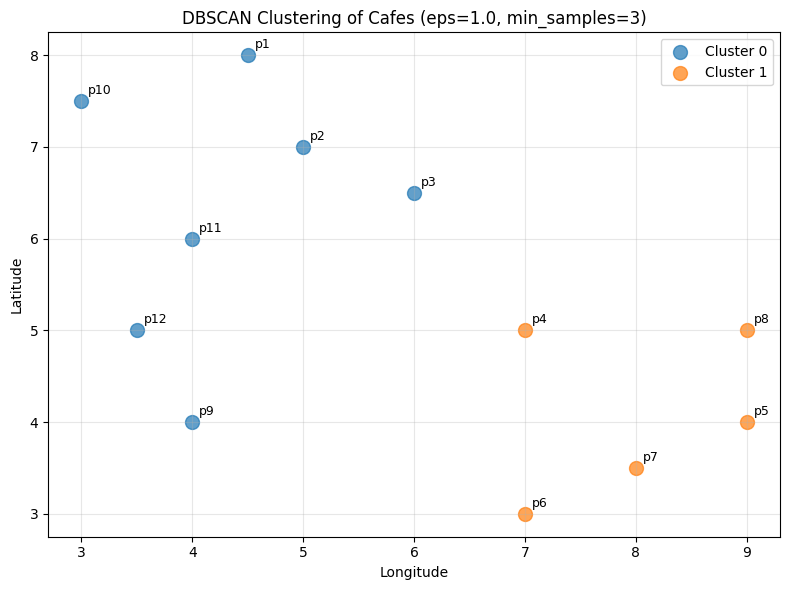

In [43]:
# VISUALIZE THE CLUSTERING RESULTS
plt.figure(figsize=(8, 6))


# PLOT EACH CLUSTER WITH DIFFERENT COLORS
for cluster in sorted(cafe_data["Cluster"].unique()):
    cluster_data = cafe_data[cafe_data["Cluster"] == cluster]
    label = f"Cluster {cluster}" if cluster != -1 else "Noise"
    plt.scatter(
        cluster_data["Longitude"],
        cluster_data["Latitude"],
        s=100,
        label=label,
        alpha=0.7,
    )


# ADD ANNOTATIONS FOR EACH CAFE
for idx, row in cafe_data.iterrows():
    plt.annotate(
        row["Cafe"],
        (row["Longitude"], row["Latitude"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )


plt.title("DBSCAN Clustering of Cafes (eps=1.0, min_samples=3)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# CALCULATE AND DISPLAY SILHOUETTE SCORE
# Higher score indicates better-defined clusters
# Note: Noise points (cluster -1) are included in the calculation
silhouette_score_value = silhouette_score(X_scaled, cafe_data["Cluster"]) * 100
print(f":> SILHOUETTE SCORE: {silhouette_score_value:.2f}")

:> SILHOUETTE SCORE: 49.63


In [35]:
# INTERPRET THE SILHOUETTE SCORE
if silhouette_score_value > 70:
    print(">> ✓ Excellent clustering quality (well-separated clusters)")
elif silhouette_score_value > 50:
    print(">> ✓ Good clustering quality (reasonable cluster separation)")
elif silhouette_score_value > 30:
    print(">> ⚠ Fair clustering quality (some overlapping clusters)")
else:
    print(">> ✗ Poor clustering quality (weak cluster structure)")

>> ⚠ Fair clustering quality (some overlapping clusters)


In [41]:
# DISPLAY CLUSTER SUMMARY STATISTICS
print("=>> CLUSTER SUMMARY STATISTICS >>")
print("=" * 35)
cluster_summary = cafe_data.groupby("Cluster").size().reset_index(name="Count")
cluster_summary["Type"] = cluster_summary["Cluster"].apply(
    lambda x: "Noise" if x == -1 else f"Cluster {x}"
)
print(cluster_summary[["Type", "Count"]].to_string(index=False))

=>> CLUSTER SUMMARY STATISTICS >>
     Type  Count
Cluster 0      7
Cluster 1      5
